### Imports


In [50]:
from data_processing import wrangle
from pathlib import Path
from sklearn.metrics import mean_absolute_error
from sklearn.pipeline import make_pipeline
from category_encoders import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import pandas as pd
import matplotlib.pyplot as plt

import xgboost as xgb
import seaborn as sns
import numpy as np
from sklearn.model_selection import GridSearchCV, cross_val_score, train_test_split, RandomizedSearchCV
from sklearn.compose import TransformedTargetRegressor

In [51]:
df = wrangle('../data/SeoulRealEstate.csv')
df.head()

,lat,lng,households,score,m2,p,avg_sales,build_year,build_month,building_age
0,37.681604,127.056592,492,4.3,139,42,61000.0,2000,6,26
1,37.679290,127.057021,468,4.1,105,32,51000.0,2001,5,25
2,37.676882,127.058075,57,4.8,86,26,40500.0,2005,2,21
3,37.675277,127.060001,216,4.8,102,31,34500.0,1995,9,31
4,37.676381,127.058361,165,4.8,91,28,40000.0,2003,6,23


In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3931 entries, 0 to 3930
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   lat           3931 non-null   float64
 1   lng           3931 non-null   float64
 2   households    3931 non-null   int64  
 3   score         3931 non-null   float64
 4   m2            3931 non-null   int64  
 5   p             3931 non-null   int64  
 6   avg_sales     3931 non-null   float64
 7   build_year    3931 non-null   int64  
 8   build_month   3931 non-null   int64  
 9   building_age  3931 non-null   int64  
dtypes: float64(4), int64(6)
memory usage: 307.2 KB


Split data into feature matrix and target vector 

In [53]:
X = df[["lat", "lng", "households", "score", "m2", "p", "build_year", "build_month", "building_age"]]
y = df["avg_sales"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,  # 20% for testing
    random_state=42,  # For reproducibility
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

Training set: 3144 samples
Test set: 787 samples


### Baseline

In [54]:
# df["avg_sales"].min()
df["avg_sales"].max()

362000.0

In [55]:
y_mean = y_train.mean()
y_pred_baseline = [y_mean] * len(X_train)
baseline_mae = mean_absolute_error(y_pred_baseline, y_train)
print("Mean apt price:", y_mean)
print("Baseline MAE:", baseline_mae)

Mean apt price: 46685.78244274809
Baseline MAE: 18219.81230454713


### Modeling

Noticed overfitting in XGBoost model so I made the simplified model shallower and revised the tuning grid

In [56]:
ridge_pipeline = TransformedTargetRegressor(
    regressor=Pipeline([
        ('scaler', StandardScaler()),
        ('ridge', Ridge())
    ]),
    func=np.log1p,  # Use log1p for better handling of zeros/small values
    inverse_func=np.expm1
)

xgb_simple = TransformedTargetRegressor(
    regressor=xgb.XGBRegressor(
        objective='reg:squarederror',
        n_estimators=100,
        max_depth=3,                 # Shallower tree to reduce overfitting
        learning_rate=0.1,
        subsample=0.8,
        random_state=42,
        n_jobs=-1
    ),
    func=np.log1p,
    inverse_func=np.expm1
)

xgb_for_tuning = TransformedTargetRegressor(
    regressor=xgb.XGBRegressor(
        objective='reg:squarederror',
        random_state=42,
        n_jobs=-1
    ),
    func=np.log1p,
    inverse_func=np.expm1
)


param_grid = {
    'regressor__n_estimators': [500, 1000],
    'regressor__learning_rate': [0.01, 0.03],
    'regressor__max_depth': [3, 4, 5],
    'regressor__subsample': [0.6, 0.7, 0.8],
    'regressor__colsample_bytree': [0.6, 0.7],
    'regressor__reg_alpha': [1, 5, 10],
    'regressor__reg_lambda': [10, 20],
    'regressor__min_child_weight': [5, 10, 15]
}

xgb_tuned = RandomizedSearchCV(
    xgb_for_tuning, 
    param_grid, 
    n_iter=30,  # Try 30 random combinations (instead of all 3^7=2187)
    cv=5, 
    scoring='neg_mean_squared_error',
    verbose=1,
    random_state=42,
    n_jobs=-1
)

In [74]:
models = {
    'Ridge (Baseline)': ridge_pipeline,
    'XGBoost (Simple)': xgb_simple,
    'XGBoost (Tuned)': xgb_tuned
}

# Store results for train AND test
train_results = {}
test_results = {}

print("Training models...")
print("=" * 70)

for name, model in models.items():
    print(f"\nTraining {name}...")
    
    # Fit model
    model.fit(X_train, y_train)
    
    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Calculate metrics - handle MAPE carefully (avoid division by zero)
    def safe_mape(y_true, y_pred):
        # Filter out zero values to avoid division by zero
        mask = y_true != 0
        if np.sum(mask) == 0:
            return np.nan
        return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    
    # Training metrics
    train_results[name] = {
        'RMSE': np.sqrt(mean_squared_error(y_train, y_train_pred)),
        'MAE': mean_absolute_error(y_train, y_train_pred),
        'R²': r2_score(y_train, y_train_pred),
        'MAPE': safe_mape(y_train, y_train_pred)
    }
    
    # Testing metrics (THIS IS WHAT MATTERS!)
    test_results[name] = {
        'RMSE': np.sqrt(mean_squared_error(y_test, y_test_pred)),
        'MAE': mean_absolute_error(y_test, y_test_pred),
        'R²': r2_score(y_test, y_test_pred),
        'MAPE': safe_mape(y_test, y_test_pred)
    }
    
    print(f"  Training R²: {train_results[name]['R²']:.4f}")
    print(f"  Testing R²:  {test_results[name]['R²']:.4f}")

# ==================== DISPLAY RESULTS ====================

print("\n" + "=" * 70)
print("MODEL COMPARISON - TRAINING SET")
print("=" * 70)
train_df = pd.DataFrame(train_results).T
print(train_df.round(4))

print("\n" + "=" * 70)
print("MODEL COMPARISON - TESTING SET (MORE IMPORTANT)")
print("=" * 70)
test_df = pd.DataFrame(test_results).T
print(test_df.round(4))

# ==================== ADDITIONAL ANALYSIS ====================

# Check if XGBoost (Tuned) found better parameters
if 'XGBoost (Tuned)' in models:
    print("\n" + "=" * 70)
    print("XGBOOST TUNING RESULTS")
    print("=" * 70)
    print(f"Best parameters: {xgb_tuned.best_params_}")
    print(f"Best cross-validation score: {-xgb_tuned.best_score_:.2f} (negative MSE)")

# ==================== QUICK VISUALIZATION ====================

# Optional: Create a summary comparison
print("\n" + "=" * 70)
print("PERFORMANCE SUMMARY - TEST SET")
print("=" * 70)

# Create a clean summary dataframe
summary_data = []
for model_name in test_results.keys():
    summary_data.append({
        'Model': model_name,
        'Test_RMSE': test_results[model_name]['RMSE'],
        'Test_MAE': test_results[model_name]['MAE'],
        'Test_R²': test_results[model_name]['R²'],
        'Test_MAPE%': test_results[model_name]['MAPE']
    })

summary_df = pd.DataFrame(summary_data)
summary_df = summary_df.sort_values('Test_R²', ascending=False)
print(summary_df.to_string(index=False))

print("\n" + "=" * 70)
print("KEY INSIGHTS:")
print("=" * 70)

# Find best model
best_model = summary_df.iloc[0]['Model']
best_r2 = summary_df.iloc[0]['Test_R²']

# Check for overfitting
print("\n3. Overfitting check (Train R² - Test R²):")
for name in train_results.keys():
    overfit_gap = train_results[name]['R²'] - test_results[name]['R²']
    if overfit_gap > 0.1:
        print(f"   ⚠️  {name}: Gap = {overfit_gap:.3f} (Possible overfitting!)")
    else:
        print(f"   ✓ {name}: Gap = {overfit_gap:.3f}")

Training models...

Training Ridge (Baseline)...
  Training R²: 0.4413
  Testing R²:  0.3277

Training XGBoost (Simple)...
  Training R²: 0.7933
  Testing R²:  0.6722

Training XGBoost (Tuned)...
Fitting 5 folds for each of 30 candidates, totalling 150 fits
  Training R²: 0.8815
  Testing R²:  0.7624

MODEL COMPARISON - TRAINING SET
                        RMSE         MAE      R²     MAPE
Ridge (Baseline)  21442.4539  12840.5515  0.4413  28.1607
XGBoost (Simple)  13041.5090   7477.0335  0.7933  16.2128
XGBoost (Tuned)    9874.9645   5249.6158  0.8815  11.2688

MODEL COMPARISON - TESTING SET (MORE IMPORTANT)
                        RMSE         MAE      R²     MAPE
Ridge (Baseline)  20519.7384  12917.9530  0.3277  29.5743
XGBoost (Simple)  14329.6434   8317.1394  0.6722  19.1832
XGBoost (Tuned)   12199.6019   7193.0139  0.7624  17.0507

XGBOOST TUNING RESULTS
Best parameters: {'regressor__subsample': 0.6, 'regressor__reg_lambda': 20, 'regressor__reg_alpha': 1, 'regressor__n_estimators'

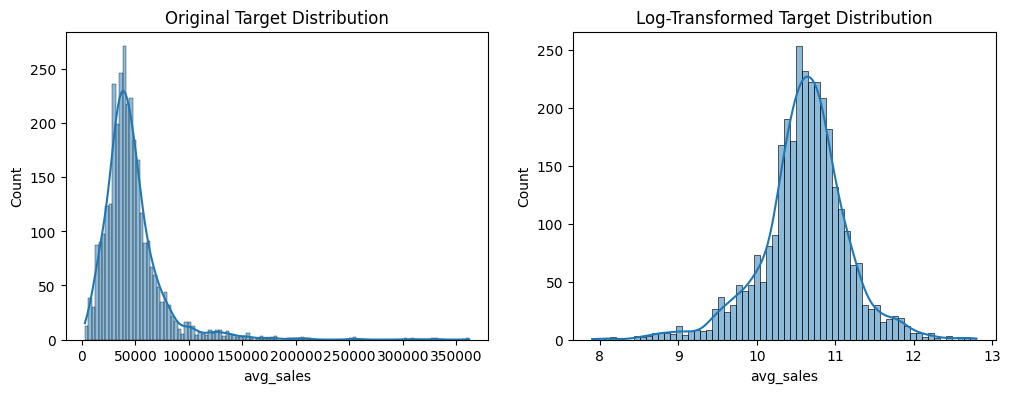

In [68]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(y_train, ax=axes[0], kde=True)
axes[0].set_title('Original Target Distribution')
sns.histplot(np.log1p(y_train), ax=axes[1], kde=True)
axes[1].set_title('Log-Transformed Target Distribution')
plt.show()

**Feature Importance (Gain)**
This chart illustrates the contribution of each feature to the model's predictive power. The dominance of m2 (size) and coordinates aligns with real estate valuation fundamentals. Notably, the Distance to Gangnam and raw Latitude and Longitude serve as 

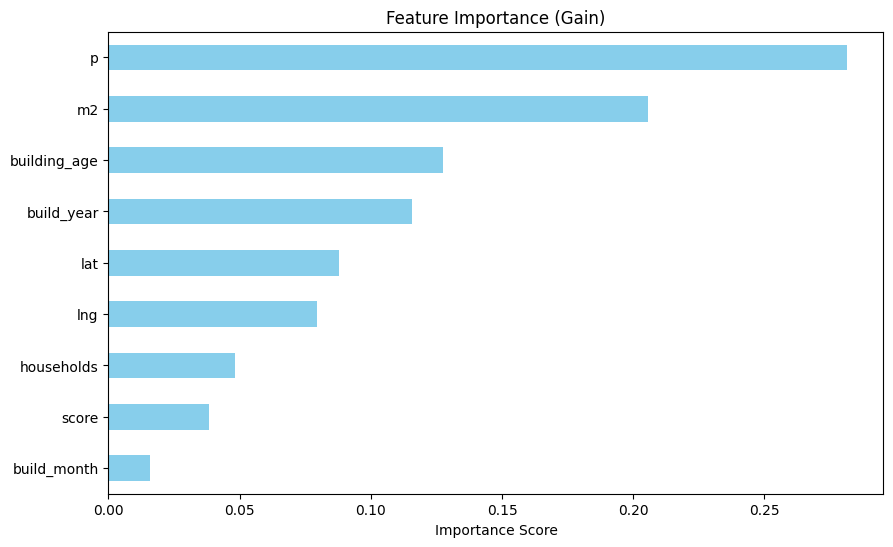

In [76]:
model = xgb_tuned.best_estimator_.regressor_
feature_names = X_train.columns

importances = pd.Series(model.feature_importances_, index=feature_names)
importances.sort_values().plot(kind='barh', figsize=(10, 6), color='skyblue')
plt.title('Feature Importance (Gain)')
plt.xlabel('Importance Score')
plt.show()

**Actual vs. Predicted Price**

The scatter plot compares the model's prediction against actual transaction prices. The proximity of the data points to the dashed line signifies a strong correlation (R^2 = 0.76). While the model is highly accurate for the majority of the market, the increased dispersion at higher actual prices and predicted prices indicates that as prices exceed 100,000 Won, the model begins to both overestimate and underestimate. This is likely due to missing subjective features such as interior quality, or landmark views.

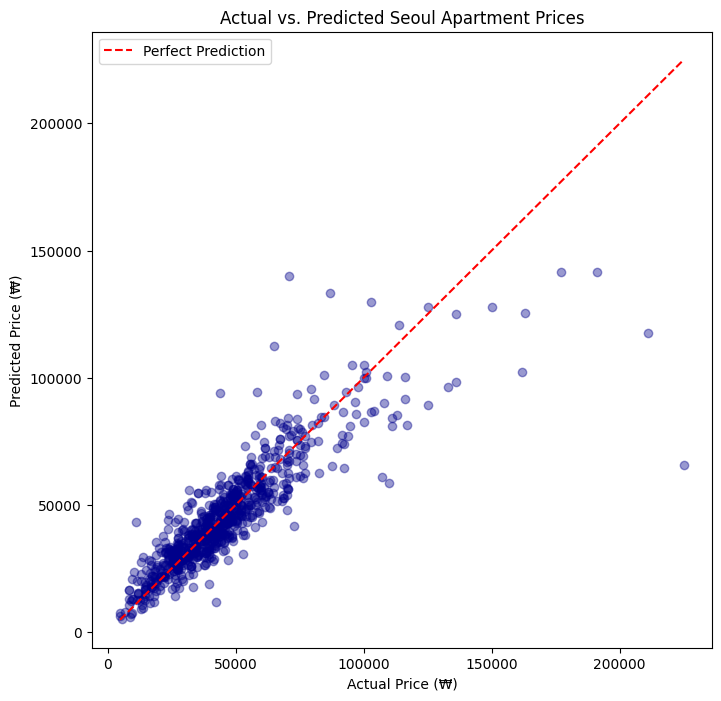

In [69]:
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred, alpha=0.4, color='darkblue')

# Draw the 45-degree line of perfection
max_val = max(max(y_test), max(y_pred))
min_val = min(min(y_test), min(y_pred))
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Perfect Prediction')

plt.xlabel('Actual Price (₩)')
plt.ylabel('Predicted Price (₩)')
plt.title('Actual vs. Predicted Seoul Apartment Prices')
plt.legend()
plt.show()

**Standard Residual Plot (Predicted vs Error)**

The residual plot acts as a diagnostic tool for model bias. Here we observe heteroscedasticity, where the variance of errors increases alongside the predicted price. The observed funnel shape confirms the inaccuracy of the model is largely driven by outliers.

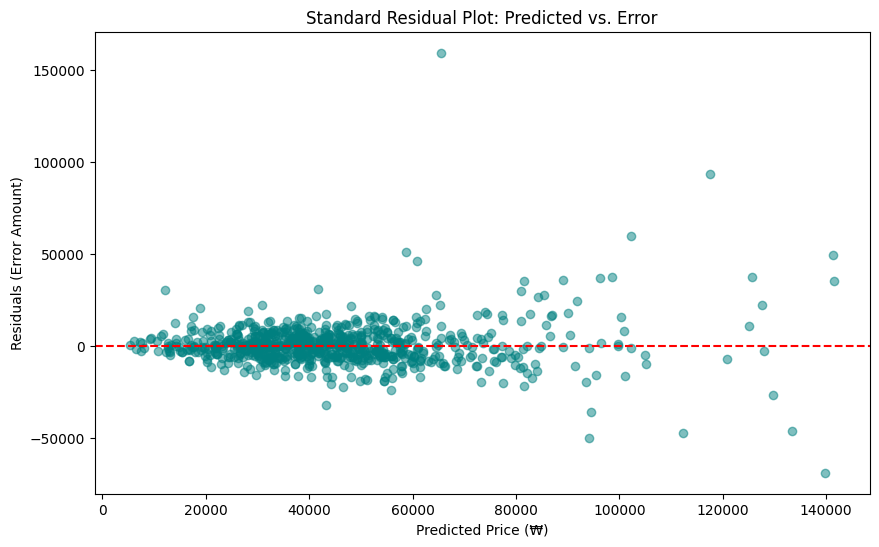

In [67]:
y_pred = xgb_tuned.predict(X_test)
residuals = y_test - y_pred

plt.figure(figsize=(10, 6))
plt.scatter(y_pred, residuals, alpha=0.5, color='teal')
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Price (₩)')
plt.ylabel('Residuals (Error Amount)')
plt.title('Standard Residual Plot: Predicted vs. Error')
plt.show()

In [72]:
import folium
from folium.plugins import HeatMap

# Create a base map centered on Seoul
m = folium.Map(location=[37.5665, 126.9780], zoom_start=11)

# Add a heatmap of actual prices
heat_data = [[row['lat'], row['lng'], row['p']] for index, row in df.iterrows()]
HeatMap(heat_data, radius=15, blur=20, gradient={0.4: 'blue', 0.65: 'lime', 1: 'red'}).add_to(m)

# Save to html to view in browser
m.save("seoul_price_heatmap.html")